In [324]:
!pip install Sastrawi

In [325]:

dokumen = {
    "d1": "Dosen-dosen Unitama sedang melaksanakan rapat koordinasi dosen di aula kampus Unitama.",
    "d2": "Pasnur merupakan salah seorang dosen di kampus Unitama Makassar.",
    "d3": "Bagaimana keakraban dosen-dosen dan mahasiswa-mahasiswa di kampus Unitama?",
    "d4": "Kota Makassar merupakan kota terbesar di Sulawesi Selatan dan dicanangkan sebagai kota dunia.",
    "d5": "Perkenalkan nama saya Muhammad Bintang Ramli, saya berasal dari Kota Makassar Kelurahan Sudiang, Saya Suka Membaca Buku, Dan Belajar Koding 😁👍.",
    "d6": "Saya merasa mata kuliah sistem temu kembali informasi cukup menarik untuk dipelajari, dan saya berharap disini saya mendapatkan ilmu yang banyak karena saya suka sekali dengan STKI (sistem temu kembali).",
    "q": "Dosen Unitama Makassar"
}

In [326]:
import pandas as pd

df = pd.DataFrame(list(dokumen.items()), columns=["id_dokumen", "isi_dokumen"])
df

,id_dokumen,isi_dokumen
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...
1,d2,Pasnur merupakan salah seorang dosen di kampus...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...
4,d5,"Perkenalkan nama saya Muhammad Bintang Ramli, ..."
5,d6,Saya merasa mata kuliah sistem temu kembali in...
6,q,Dosen Unitama Makassar


In [327]:
def case_folding(text):
    return text.lower()

In [328]:
df["isi_casefold"] = df["isi_dokumen"].apply(case_folding)
df

,id_dokumen,isi_dokumen,isi_casefold
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...,dosen-dosen unitama sedang melaksanakan rapat ...
1,d2,Pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen-dosen dan mahasiswa-...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...,kota makassar merupakan kota terbesar di sulaw...
4,d5,"Perkenalkan nama saya Muhammad Bintang Ramli, ...","perkenalkan nama saya muhammad bintang ramli, ..."
5,d6,Saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...
6,q,Dosen Unitama Makassar,dosen unitama makassar


In [329]:
import re

def filtering(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [330]:
df["isi_filtered"] = df["isi_casefold"].apply(filtering)
df

,id_dokumen,isi_dokumen,isi_casefold,isi_filtered
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...,dosen-dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...
1,d2,Pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen dosen dan mahasiswa ...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar di sulaw...
4,d5,"Perkenalkan nama saya Muhammad Bintang Ramli, ...","perkenalkan nama saya muhammad bintang ramli, ...",perkenalkan nama saya muhammad bintang ramli s...
5,d6,Saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...
6,q,Dosen Unitama Makassar,dosen unitama makassar,dosen unitama makassar


In [331]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()

def remove_stopword(text):
    return stopword.remove(text)

In [332]:
df["isi_stopword"] = df["isi_filtered"].apply(remove_stopword)
df

,id_dokumen,isi_dokumen,isi_casefold,isi_filtered,isi_stopword
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...,dosen-dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...
1,d2,Pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen kampus un...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen dosen dan mahasiswa ...,bagaimana keakraban dosen dosen mahasiswa maha...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar sulawesi...
4,d5,"Perkenalkan nama saya Muhammad Bintang Ramli, ...","perkenalkan nama saya muhammad bintang ramli, ...",perkenalkan nama saya muhammad bintang ramli s...,perkenalkan nama muhammad bintang ramli berasa...
5,d6,Saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,merasa mata kuliah sistem temu informasi cukup...
6,q,Dosen Unitama Makassar,dosen unitama makassar,dosen unitama makassar,dosen unitama makassar


In [333]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

In [334]:
df["isi_stem"] = df["isi_stopword"].apply(stemming)
df

,id_dokumen,isi_dokumen,isi_casefold,isi_filtered,isi_stopword,isi_stem
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...,dosen-dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang laksana rapat koord...
1,d2,Pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen kampus un...,pasnur rupa salah orang dosen kampus unitama m...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen dosen dan mahasiswa ...,bagaimana keakraban dosen dosen mahasiswa maha...,bagaimana akrab dosen dosen mahasiswa mahasisw...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar sulawesi...,kota makassar rupa kota besar sulawesi selatan...
4,d5,"Perkenalkan nama saya Muhammad Bintang Ramli, ...","perkenalkan nama saya muhammad bintang ramli, ...",perkenalkan nama saya muhammad bintang ramli s...,perkenalkan nama muhammad bintang ramli berasa...,kenal nama muhammad bintang ramli asal kota ma...
5,d6,Saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,merasa mata kuliah sistem temu informasi cukup...,rasa mata kuliah sistem temu informasi cukup t...
6,q,Dosen Unitama Makassar,dosen unitama makassar,dosen unitama makassar,dosen unitama makassar,dosen unitama makassar


In [335]:
df_clean = df[["id_dokumen", "isi_stem"]].copy()
df_clean.columns = ["id_dokumen", "isi_dokumen"]
df_clean

,id_dokumen,isi_dokumen
0,d1,dosen dosen unitama sedang laksana rapat koord...
1,d2,pasnur rupa salah orang dosen kampus unitama m...
2,d3,bagaimana akrab dosen dosen mahasiswa mahasisw...
3,d4,kota makassar rupa kota besar sulawesi selatan...
4,d5,kenal nama muhammad bintang ramli asal kota ma...
5,d6,rasa mata kuliah sistem temu informasi cukup t...
6,q,dosen unitama makassar


In [336]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_clean["isi_dokumen"])

tf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df_clean["id_dokumen"]
)

tf_transpose = tf_df.T

tf_transpose.reset_index(inplace=True)
tf_transpose.rename(columns={"index": "Term/Kata"}, inplace=True)

tf_transpose



id_dokumen,Term/Kata,d1,d2,d3,d4,d5,d6,q
0,ajar,0,0,0,0,1,1,0
1,akrab,0,0,1,0,0,0,0
2,asal,0,0,0,0,1,0,0
3,aula,1,0,0,0,0,0,0
4,baca,0,0,0,0,1,0,0
5,bagaimana,0,0,1,0,0,0,0
6,banyak,0,0,0,0,0,1,0
7,besar,0,0,0,1,0,0,0
8,bintang,0,0,0,0,1,0,0
9,buku,0,0,0,0,1,0,0


In [337]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer(
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=False,
    norm=None
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean["isi_dokumen"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_df.insert(0, "id_dokumen", df_clean["id_dokumen"])

tfidf_df

,id_dokumen,ajar,akrab,asal,aula,baca,bagaimana,banyak,besar,bintang,...,selatan,sini,sistem,stki,sudiang,suka,sulawesi,tarik,temu,unitama
0,d1,0.000000,0.000000,0.000000,2.386294,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.940007
1,d2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.470004
2,d3,0.000000,2.386294,0.000000,0.000000,0.000000,2.386294,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.470004
3,d4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.386294,0.000000,...,2.386294,0.000000,0.000000,0.000000,0.000000,0.000000,2.386294,0.000000,0.000000,0.000000
4,d5,1.980829,0.000000,2.386294,0.000000,2.386294,0.000000,0.000000,0.000000,2.386294,...,0.000000,0.000000,0.000000,0.000000,2.386294,1.980829,0.000000,0.000000,0.000000,0.000000
5,d6,1.980829,0.000000,0.000000,0.000000,0.000000,0.000000,2.386294,0.000000,0.000000,...,0.000000,2.386294,4.772589,2.386294,0.000000,1.980829,0.000000,2.386294,4.772589,0.000000
6,q,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.470004


In [338]:
import numpy as np

query_vec = tfidf_df[tfidf_df["id_dokumen"] == "q"].drop(columns=["id_dokumen"]).values[0]

hasil = []

for i, row in tfidf_df.iterrows():
    if row["id_dokumen"] == "q":
        continue

    doc_vec = row.drop("id_dokumen").values

    dot = np.dot(query_vec, doc_vec)
    norm_q = np.linalg.norm(query_vec)
    norm_d = np.linalg.norm(doc_vec)

    sim = dot / (norm_q * norm_d)

    hasil.append((row["id_dokumen"], sim))

sim_df = pd.DataFrame(hasil, columns=["id_dokumen", "cosine_similarity"])
sim_df = sim_df.sort_values(by="cosine_similarity", ascending=False)

sim_df

,id_dokumen,cosine_similarity
0,d1,0.550456
1,d2,0.462119
2,d3,0.368124
3,d4,0.101534
4,d5,0.096990
5,d6,0.000000


In [339]:
threshold = 0.2

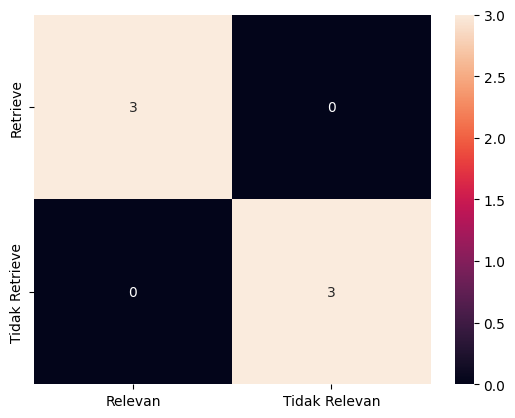

In [340]:
import seaborn as sns
import matplotlib.pyplot as plt

relevansi = {
    "d1":1, "d2":1, "d3":1,
    "d4":0, "d5":0, "d6":0
}

sim_df["prediksi"] = sim_df["cosine_similarity"].apply(lambda x: 1 if x >= threshold else 0)
sim_df["aktual"] = sim_df["id_dokumen"].map(relevansi)

TP = len(sim_df[(sim_df.prediksi==1)&(sim_df.aktual==1)])
FP = len(sim_df[(sim_df.prediksi==1)&(sim_df.aktual==0)])
FN = len(sim_df[(sim_df.prediksi==0)&(sim_df.aktual==1)])
TN = len(sim_df[(sim_df.prediksi==0)&(sim_df.aktual==0)])

cm = [[TP, FP],[FN, TN]]

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Relevan","Tidak Relevan"],
            yticklabels=["Retrieve","Tidak Retrieve"])
plt.show()

In [341]:
precision = TP/(TP+FP)
recall = TP/(TP+FN)
f1 = 2*(precision*recall)/(precision+recall)
accuracy = (TP+TN)/(TP+TN+FP+FN)

print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TN:", TN)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)

TP: 3
FP: 0
FN: 0
TN: 3
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Accuracy: 1.0
